In [1]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *

sfreq=250
paradigm = LeftRightImagery(resample=sfreq)
datasets = [
    BNCI2014004()
]


BNCI2014004 has been renamed to BNCI2014_004. BNCI2014004 will be removed in version 1.1.
The dataset class name 'BNCI2014004' must be an abbreviation of its code 'BNCI2014-004'. See moabb.datasets.base.is_abbrev for more information.


In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import warnings
from joblib import parallel_backend
from joblib import Parallel
from hoda.classification import SelectF
from sklearn.pipeline import make_pipeline
import tensorly as tl

clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=2,
    truncate=False,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    clf=clf,
)

In [4]:
import tensorly as tl
import pandas as pd
from hoda.tensorize import stf_tensor

select_infos = []
train_infos = []
for dataset in datasets:
    for subject in dataset.subject_list:
        epochs, labels, meta = paradigm.get_data(
            dataset=dataset, 
             subjects=[subject],
             return_epochs=True
        )
        for session in meta['session'].unique()[:1]:
            idc = meta['session'] == session
            epochs_ses = epochs[idc]
            labels_ses = labels[idc]
            meta_ses = meta[idc]

            X = epochs_ses.get_data()
            X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True,log=True)
            X = tl.tensor(X)
            y = labels_ses

            print(f'dataset={dataset.code} subject={subject} session={session}')
            bttda.fit(X,y, test=True)
            subj_select_info = pd.DataFrame(bttda.model_select_info_best_) 
            subj_select_info['dataset'] = dataset.code
            subj_select_info['subject'] = subject
            subj_select_info['session'] = session
            subj_train_info = pd.DataFrame(bttda.train_info_)
            subj_train_info['dataset'] = dataset.code
            subj_train_info['subject'] = subject
            subj_train_info['session'] = session
            select_infos.append(subj_select_info.reset_index())
            train_infos.append(subj_train_info.reset_index())
            # save
            select_info = pd.concat(select_infos, ignore_index=True)
            train_info = pd.concat(train_infos, ignore_index=True)
            select_info.to_csv('block_mi_select.csv')
            train_info.to_csv('block_mi_train.csv')


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
720 matching events found
No baseline correction applied
Setting up band-pass filter from 8 - 11 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 11.31 Hz
- Upper transition bandwidth: 2.83 Hz (-6 dB cutoff frequency: 12.73 Hz)
- Filter length: 413 samples (1.652 s)



/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr

Setting up band-pass filter from 11 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 11.31
- Lower transition bandwidth: 2.83 Hz (-6 dB cutoff frequency: 9.90 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 18.00 Hz)
- Filter length: 293 samples (1.172 s)

Setting up band-pass filter from 16 - 23 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 16.00
- Lower transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 14.00 Hz)
- Upper passband edge: 22.63 Hz
- Upper transition bandwidth: 5.66 Hz (-6 dB cutoff frequency: 25.46 Hz)
-

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s


dataset=BNCI2014-004 subject=1 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.9736
Trying rank (2, 2, 2)	score: 0.9602
Trying rank (3, 4, 4)	score: 0.9518
Trying rank (3, 4, 8)	score: 0.9807
Trying rank (3, 4, 16)	score: 0.9800
Trying rank (3, 4, 18)	score: 0.9711

Selected rank (3, 4, 8) with score 0.9807
New ranks: [(3, 4, 8)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.9693
Trying rank (2, 2, 2)	score: 0.9538
Trying rank (3, 4, 4)	score: 0.9716
Trying rank (3, 4, 8)	score: 0.9713
Trying rank (3, 4, 16)	score: 0.9578
Trying rank (3, 4, 18)	score: 0.9711

Selected rank (3, 4, 4) with score 0.9716
New ranks: [(3, 4, 8), (3, 4, 4)]


Fitting block 1/2...
Fitting block 2/2...
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
680 matching events found
No baseline correction applied
Setting up band-pass filte

...

dataset=BNCI2014-004 subject=8 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.6866
Trying rank (2, 2, 2)	score: 0.6602
Trying rank (3, 4, 4)	score: 0.5626
Trying rank (3, 4, 8)	score: 0.5880
Trying rank (3, 4, 16)	score: 0.4800
Trying rank (3, 4, 18)	score: 0.5470

Selected rank (1, 1, 1) with score 0.6866
New ranks: [(1, 1, 1)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.6669
Trying rank (2, 2, 2)	score: 0.6766
Trying rank (3, 4, 4)	score: 0.6826
Trying rank (3, 4, 8)	score: 0.7000
Trying rank (3, 4, 16)	score: 0.5860
Trying rank (3, 4, 18)	score: 0.6263

Selected rank (3, 4, 8) with score 0.7000
New ranks: [(1, 1, 1), (3, 4, 8)]


Fitting block 1/2...
Fitting block 2/2...
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
720 matching events found
No baseline correction applied
Setting up band-pass filte

/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr

Setting up band-pass filter from 11 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 11.31
- Lower transition bandwidth: 2.83 Hz (-6 dB cutoff frequency: 9.90 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 18.00 Hz)
- Filter length: 293 samples (1.172 s)

Setting up band-pass filter from 16 - 23 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 16.00
- Lower transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 14.00 Hz)
- Upper passband edge: 22.63 Hz
- Upper transition bandwidth: 5.66 Hz (-6 dB cutoff frequency: 25.46 Hz)
-

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s


dataset=BNCI2014-004 subject=9 session=0train
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.7800
Trying rank (2, 2, 2)	score: 0.7778
Trying rank (3, 4, 4)	score: 0.7184
Trying rank (3, 4, 8)	score: 0.6867
Trying rank (3, 4, 16)	score: 0.7760
Trying rank (3, 4, 18)	score: 0.7029

Selected rank (1, 1, 1) with score 0.7800
New ranks: [(1, 1, 1)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.7160
Trying rank (2, 2, 2)	score: 0.7373
Trying rank (3, 4, 4)	score: 0.7520
Trying rank (3, 4, 8)	score: 0.7760
Trying rank (3, 4, 16)	score: 0.7182
Trying rank (3, 4, 18)	score: 0.7656

Selected rank (3, 4, 8) with score 0.7760
New ranks: [(1, 1, 1), (3, 4, 8)]


Fitting block 1/2...
Fitting block 2/2...


In [5]:
select_info

,block,rank,fold,train_score,val_score,n_features,test_score,dataset,subject,session
0,0,"(3, 4, 8)",0,0.993763,0.970000,96,0.902098,BNCI2014-004,1,0train
1,0,"(3, 4, 8)",1,1.000000,1.000000,96,0.818182,BNCI2014-004,1,0train
2,0,"(3, 4, 8)",2,0.995951,1.000000,96,0.909091,BNCI2014-004,1,0train
3,0,"(3, 4, 8)",3,0.998650,0.977778,96,0.839161,BNCI2014-004,1,0train
4,0,"(3, 4, 8)",4,0.998649,0.955556,96,0.874126,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...
85,1,"(3, 4, 8)",0,0.975694,0.780000,97,0.528571,BNCI2014-004,9,0train
86,1,"(3, 4, 8)",1,0.980405,0.655556,97,0.492857,BNCI2014-004,9,0train
87,1,"(3, 4, 8)",2,0.979054,0.633333,97,0.635714,BNCI2014-004,9,0train
88,1,"(3, 4, 8)",3,0.945270,0.955556,97,0.564286,BNCI2014-004,9,0train


In [6]:
select_info

,block,rank,fold,train_score,val_score,n_features,test_score,dataset,subject,session
0,0,"(3, 4, 8)",0,0.993763,0.970000,96,0.902098,BNCI2014-004,1,0train
1,0,"(3, 4, 8)",1,1.000000,1.000000,96,0.818182,BNCI2014-004,1,0train
2,0,"(3, 4, 8)",2,0.995951,1.000000,96,0.909091,BNCI2014-004,1,0train
3,0,"(3, 4, 8)",3,0.998650,0.977778,96,0.839161,BNCI2014-004,1,0train
4,0,"(3, 4, 8)",4,0.998649,0.955556,96,0.874126,BNCI2014-004,1,0train
...,...,...,...,...,...,...,...,...,...,...
85,1,"(3, 4, 8)",0,0.975694,0.780000,97,0.528571,BNCI2014-004,9,0train
86,1,"(3, 4, 8)",1,0.980405,0.655556,97,0.492857,BNCI2014-004,9,0train
87,1,"(3, 4, 8)",2,0.979054,0.633333,97,0.635714,BNCI2014-004,9,0train
88,1,"(3, 4, 8)",3,0.945270,0.955556,97,0.564286,BNCI2014-004,9,0train


<Axes: xlabel='block', ylabel='value'>

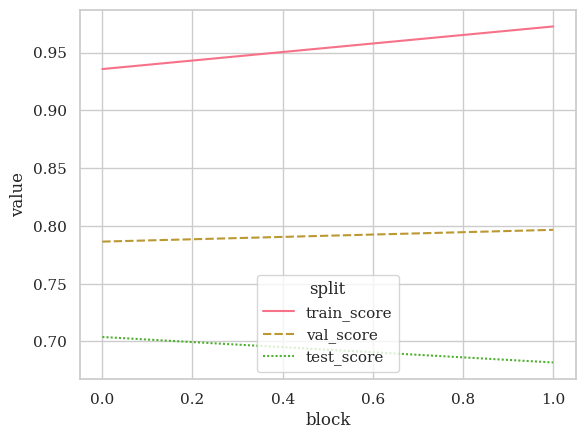

In [12]:
import seaborn as sns

idx = ['dataset', 'subject', 'session', 'block']
df = select_info.groupby(idx)[['train_score', 'val_score', 'test_score']].aggregate('mean')
df = df.melt(var_name='split', ignore_index=False)
df = df.reset_index()
sns.lineplot(data=df, x='block', y='value', hue='split', style='split', units='subject', estimator=None, errorbar=None)

In [8]:
train_info.to_csv('block_mi_train.csv')
train_info

,index,block,rank,F_tr,F_rt,log_loss,mse,nmse,dataset,subject,session
0,0,1,"(3, 4, 8)",0.000612,0.080115,0.054645,0.587595,0.587595,BNCI2014-004,1,0train
1,1,2,"(3, 4, 4)",0.000578,0.096194,0.051483,0.413067,0.413067,BNCI2014-004,1,0train
2,0,1,"(3, 4, 18)",0.000083,0.033175,0.216115,0.003365,0.003365,BNCI2014-004,2,0train
3,1,2,"(3, 4, 4)",0.000083,0.039603,0.204511,0.002586,0.002586,BNCI2014-004,2,0train
4,0,1,"(1, 1, 1)",0.005362,0.010545,0.453839,0.991754,0.991754,BNCI2014-004,3,0train
5,1,2,"(3, 4, 8)",0.000173,0.037491,0.194913,0.614950,0.614950,BNCI2014-004,3,0train
6,0,1,"(1, 1, 1)",0.019914,0.039164,0.128305,0.959751,0.959751,BNCI2014-004,4,0train
7,1,2,"(3, 4, 16)",0.000213,0.083888,0.040471,0.189971,0.189971,BNCI2014-004,4,0train
8,0,1,"(1, 1, 1)",0.008682,0.017076,0.338385,0.989716,0.989716,BNCI2014-004,5,0train
9,1,2,"(3, 4, 18)",0.000127,0.047318,0.103175,0.040263,0.040263,BNCI2014-004,5,0train


<Axes: xlabel='block', ylabel='nmse'>

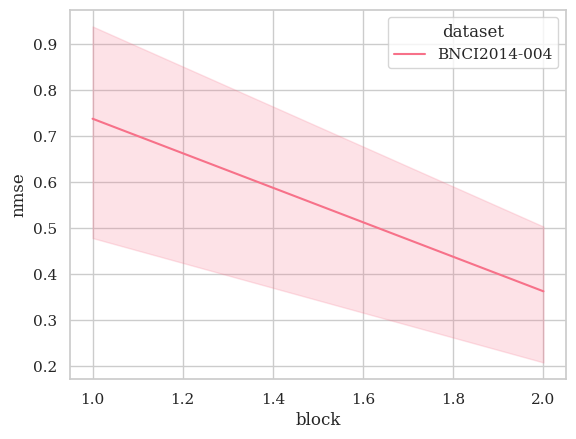

In [9]:
df = train_info.groupby(idx)
df = df['nmse'].aggregate('mean')
df = df.reset_index()
sns.lineplot(data=df, x='block',y='nmse', hue='dataset')